<a href="https://colab.research.google.com/github/Muhammad-ShahFahad/Customer_Churn_Prediction/blob/main/Customer_Churn_Pred_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import: libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier, BaggingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, PowerTransformer
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    f1_score, roc_auc_score, RocCurveDisplay
)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from scipy.stats import chi2_contingency

import joblib
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [2]:
# Load: dataset
df = pd.read_excel('Telco_customer_churn.xlsx')

Observing Dataset

In [ ]:
df.shape

(7043, 33)

In [ ]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [ ]:
for col in df.select_dtypes(exclude='number').columns:
  print(df[col].value_counts())

CustomerID
3186-AJIEK    1
3668-QPYBK    1
9237-HQITU    1
7203-OYKCT    1
9837-FWLCH    1
             ..
1066-JKSGK    1
8779-QRDMV    1
4190-MFLUW    1
0280-XJGEX    1
7892-POOKP    1
Name: count, Length: 7043, dtype: int64
Country
United States    7043
Name: count, dtype: int64
State
California    7043
Name: count, dtype: int64
City
Los Angeles      305
San Diego        150
San Jose         112
Sacramento       108
San Francisco    104
                ... 
Chester            4
Big Bar            4
Washington         4
Stonyford          4
Stirling City      4
Name: count, Length: 1129, dtype: int64
Lat Long
34.159534, -116.425984    5
33.28156, -115.955541     5
34.201108, -116.593456    5
33.798266, -118.300237    5
33.391181, -118.421305    5
                         ..
41.505916, -120.152505    4
41.764869, -122.671316    4
41.465121, -122.380947    4
40.021787, -122.127576    4
41.737962, -123.07557     4
Name: count, Length: 1652, dtype: int64
Gender
Male      3555
Female    3

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [3]:
# Check: for null values in categorical columns, where "NaN" or ""
for col in df.select_dtypes(exclude='number').columns:
  blank = df[col].replace(r"^\s*$", np.nan, regex=True).isnull().sum()
  if blank:
    print(f"{col} has {blank} blank values")


Total Charges has 11 blank values
Churn Reason has 5174 blank values


In [4]:
df.duplicated().sum()

np.int64(0)

In [6]:
for col in df.columns:
  print(col)
  print(df[col].unique())

CustomerID
['3668-QPYBK' '9237-HQITU' '9305-CDSKC' ... '2234-XADUH' '4801-JZAZL'
 '3186-AJIEK']
Count
[1]
Country
['United States']
State
['California']
City
['Los Angeles' 'Beverly Hills' 'Huntington Park' ... 'Standish' 'Tulelake'
 'Olympic Valley']
Zip Code
[90003 90005 90006 ... 96128 96134 96146]
Lat Long
['33.964131, -118.272783' '34.059281, -118.30742' '34.048013, -118.293953'
 ... '40.346634, -120.386422' '41.813521, -121.492666'
 '39.191797, -120.212401']
Latitude
[33.964131 34.059281 34.048013 ... 40.346634 41.813521 39.191797]
Longitude
[-118.272783 -118.30742  -118.293953 ... -120.386422 -121.492666
 -120.212401]
Gender
['Male' 'Female']
Senior Citizen
['No' 'Yes']
Partner
['No' 'Yes']
Dependents
['No' 'Yes']
Tenure Months
[ 2  8 28 49 10  1 47 17  5 34 11 15 18  9  7 12 25 68 55 37  3 27 20  4
 58 53 13  6 19 59 16 52 24 32 38 54 43 63 21 69 22 61 60 48 40 23 39 35
 56 65 33 30 45 46 62 70 50 44 71 26 14 41 66 64 29 42 67 51 31 57 36 72
  0]
Phone Service
['Yes' 'No']
Mult

In [7]:
numeric_features = df.select_dtypes(include='number').columns.tolist()
categorical_features = df.select_dtypes(exclude='number').columns.tolist()

In [8]:
print(numeric_features)
print(categorical_features)

['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']
['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges', 'Churn Label', 'Churn Reason']


Fix obvious data-quality issues

In [9]:
# Fix: data type of Total Charges
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [10]:
# FIX: tenure 0 customers have not been billed yet. Charge is 0.
df.loc[df['Tenure Months']==0, 'Total Charges'] = 0
df['Total Charges'] = df['Total Charges'].fillna(0)


In [11]:
# Drop: unwanted columns
df = df.drop(columns=['CustomerID', 'Count', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Country', 'State'])
# Drop: columns which might cause data leakage
df = df.drop(columns=['Churn Label', 'Churn Score', 'Churn Reason', 'CLTV'])
# Rename: target variable(Churn Value -> Churn)
df = df.rename(columns={'Churn Value': 'Churn'})


Our prediction is based on either the customer will churn or not, our target variable will be Churn

EDA

Target Variable

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


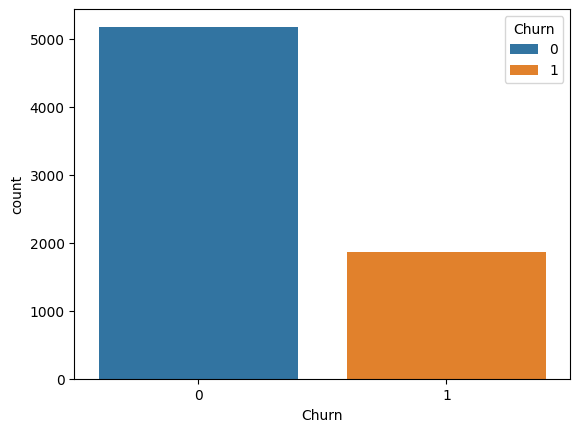

In [15]:
print(df['Churn'].value_counts(normalize=True)*100)
sns.countplot(x='Churn', data=df, hue='Churn')
plt.show()

Numeric Columns

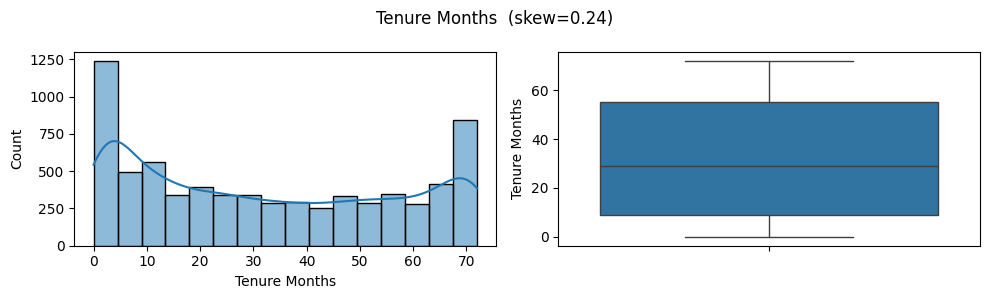

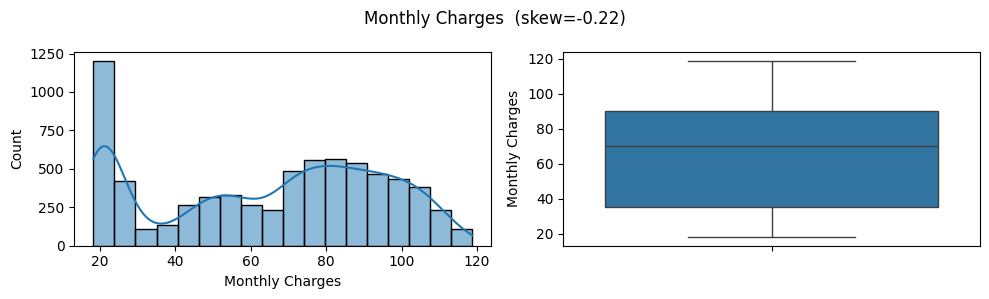

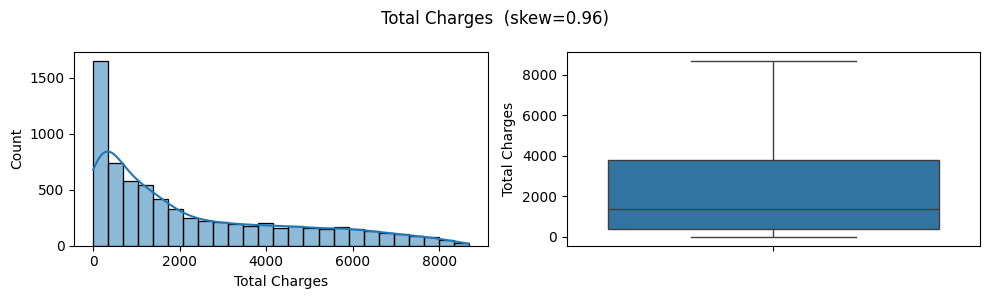

In [16]:
numeric_features = df.select_dtypes(include='number').columns
categorical_features = df.select_dtypes(exclude='number').columns
for col in numeric_features:
  if col == 'Churn':
    continue
  fig, Axes = plt.subplots(1, 2, figsize=(10, 3))
  sns.histplot(df[col], kde=True, ax=Axes[0])
  sns.boxplot(df[col], ax=Axes[1])
  fig.suptitle(f'{col}  (skew={df[col].skew():.2f})')
  plt.tight_layout()
  plt.show()


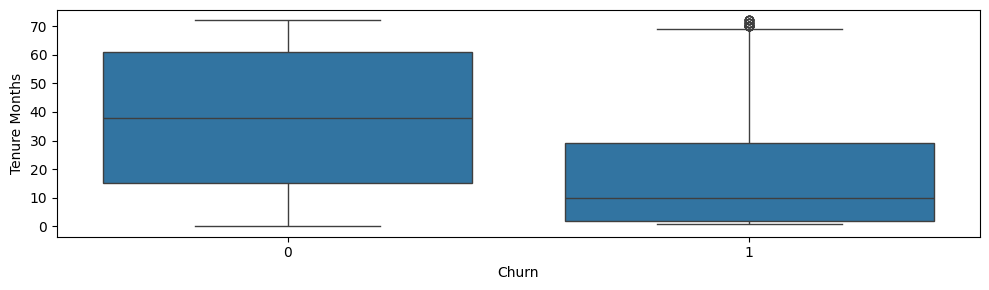

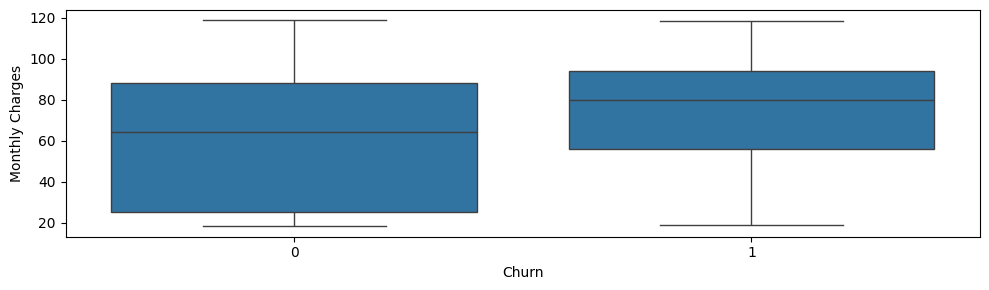

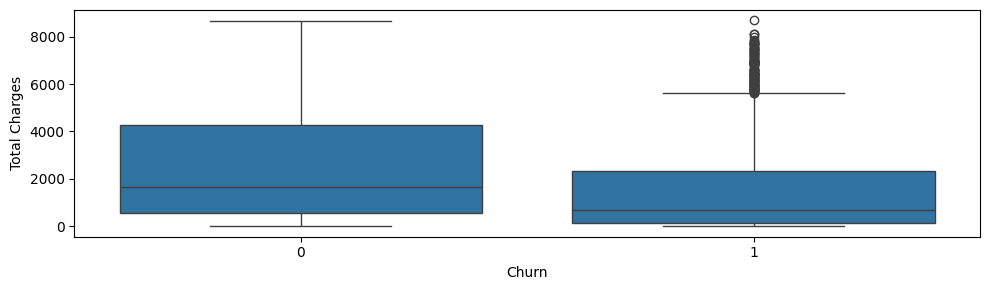

In [17]:
for col in numeric_features:
  if col == 'Churn':
    continue
  fig, Axes = plt.subplots(1, figsize=(10, 3))
  sns.boxplot(x='Churn', y=col, data=df)
  plt.tight_layout()
  plt.show()

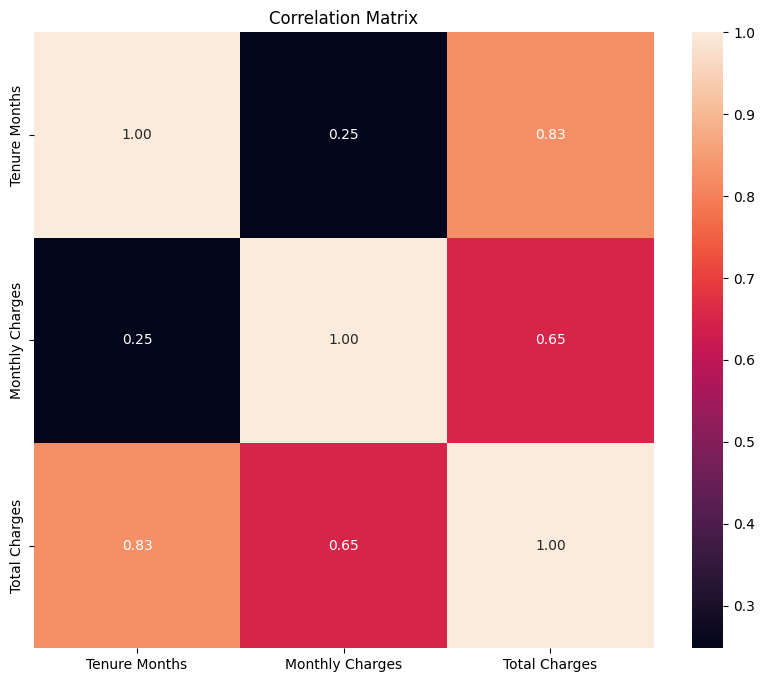

In [18]:
corr_col = [c for c in numeric_features if c != 'Churn']
plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_col].corr(), annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


Note: Total Charges are Highly correlated with Tenure Month and Monthly Charges.
It can cause multicollinearity:Redundant information: Both features tell the model the same thing, which adds unnecessary complexity without adding new value.Unstable coefficients: Model weights in linear algorithms can swing wildly and change a lot even with tiny changes in the training data.Misleading feature importance: It becomes hard to tell which of the correlated features is actually helping the model make predictions.Overfitting risk: Models can overfit the training data and perform poorly on new, unseen data

In [19]:
# Check: outliers
for col in numeric_features:
  n_unique = df[col].nunique(dropna=True)
  if n_unique <= 2:
    continue
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr
  n_out = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
  print(f'{col} has {n_out} outliers')


Tenure Months has 0 outliers
Monthly Charges has 0 outliers
Total Charges has 0 outliers


For categorica features

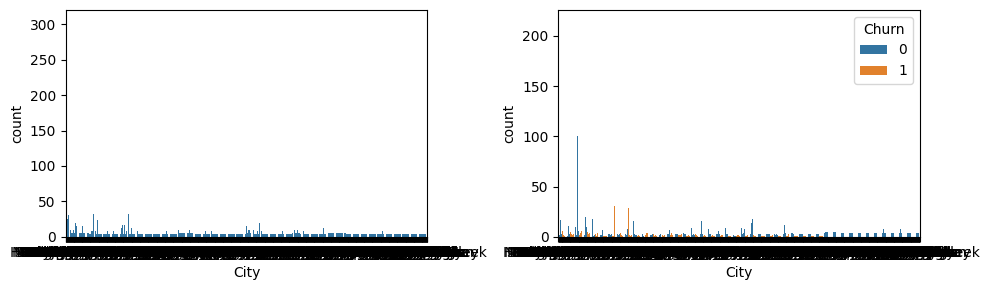

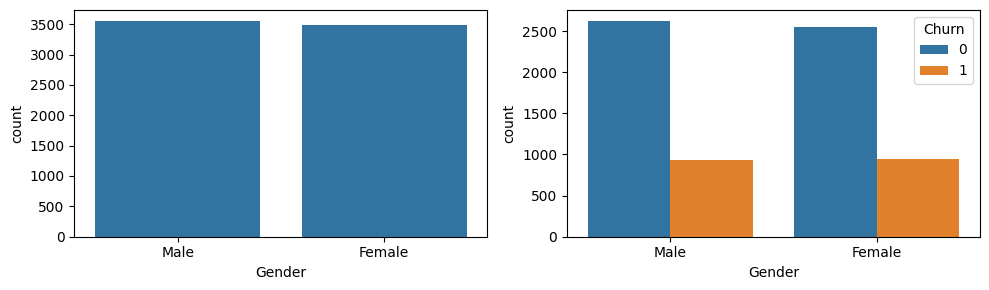

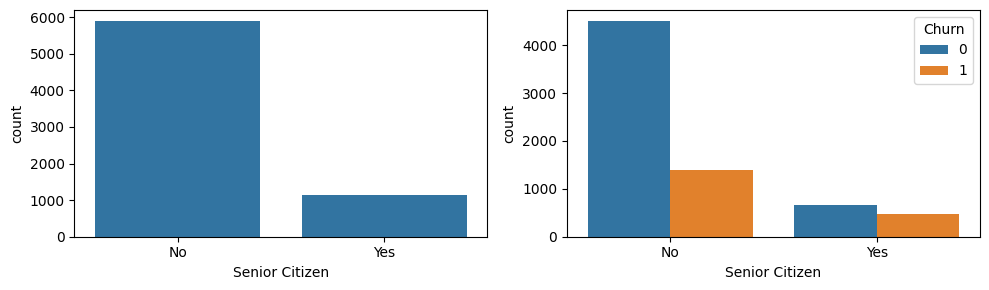

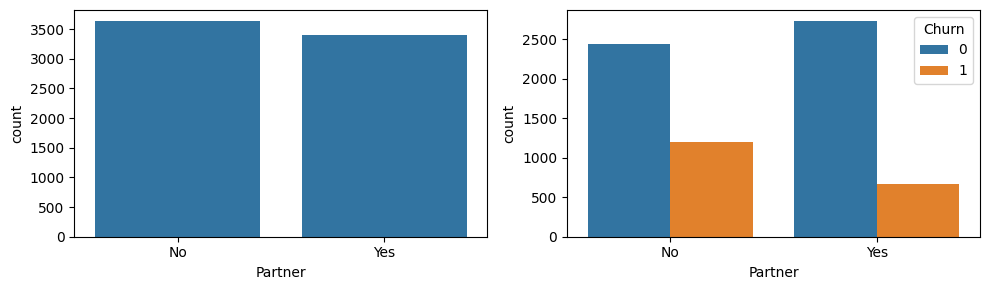

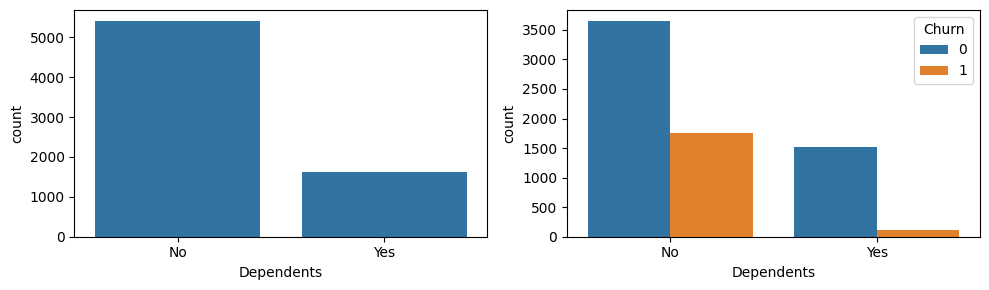

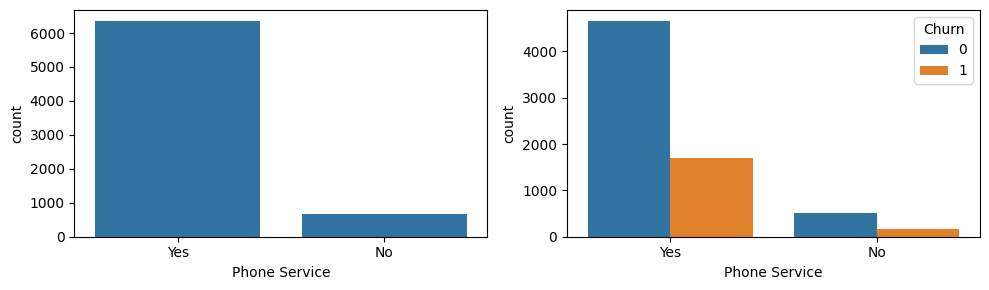

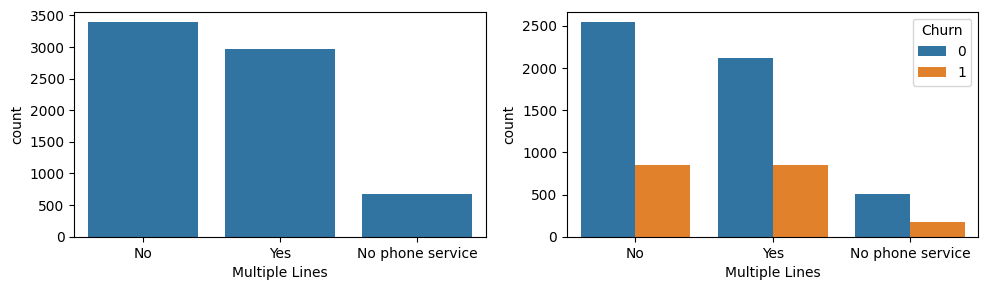

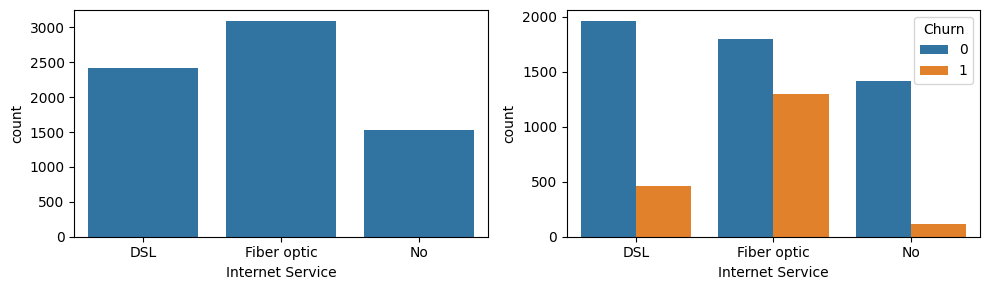

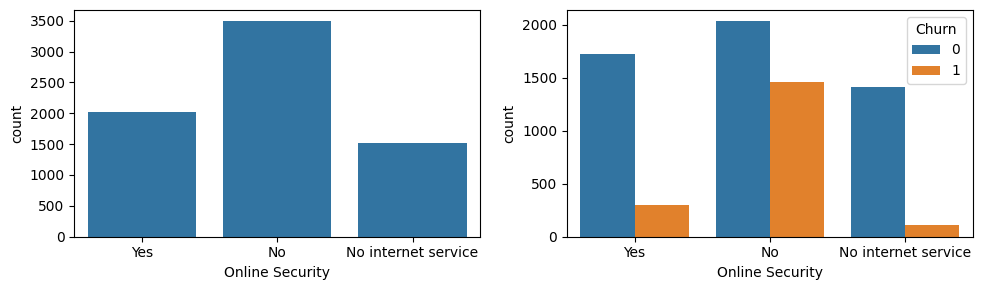

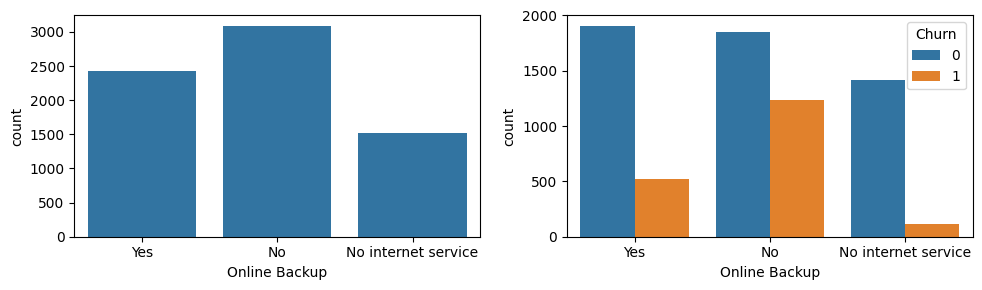

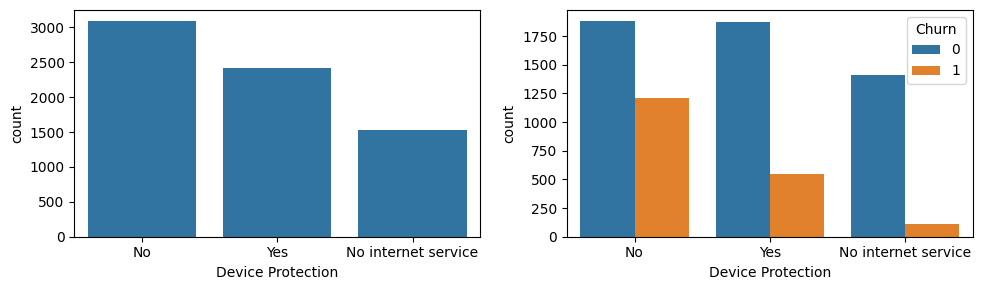

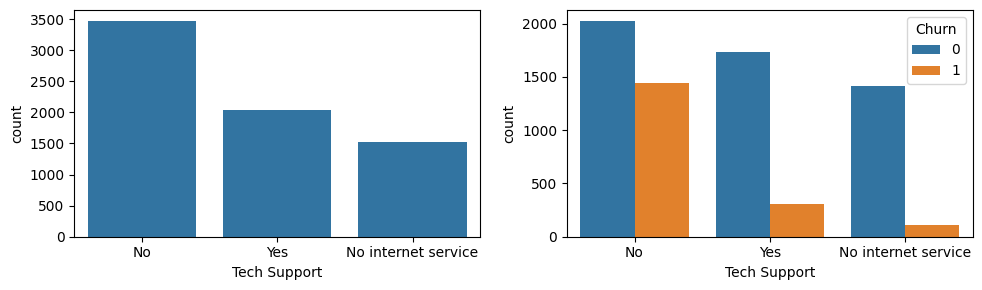

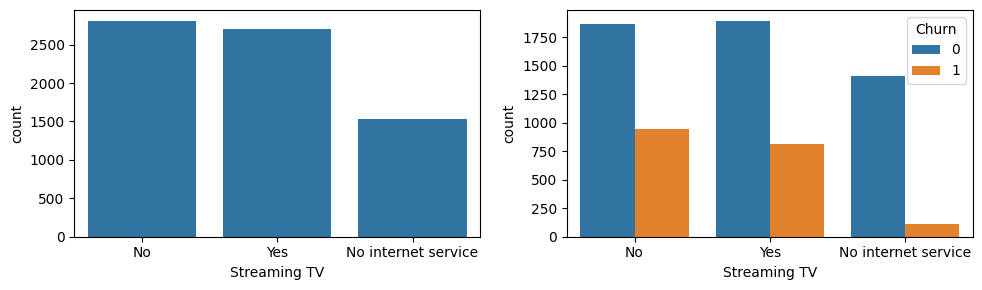

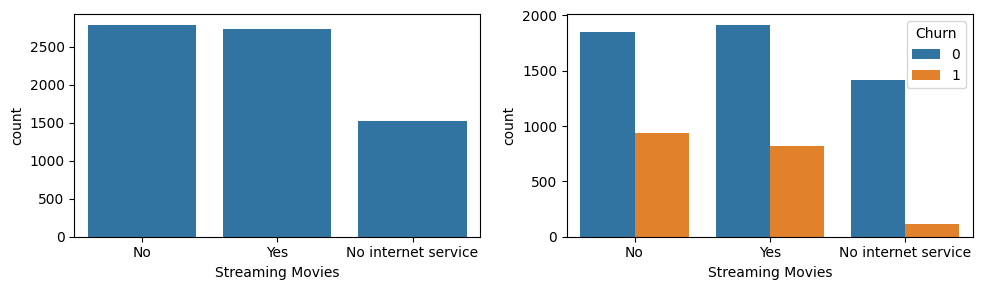

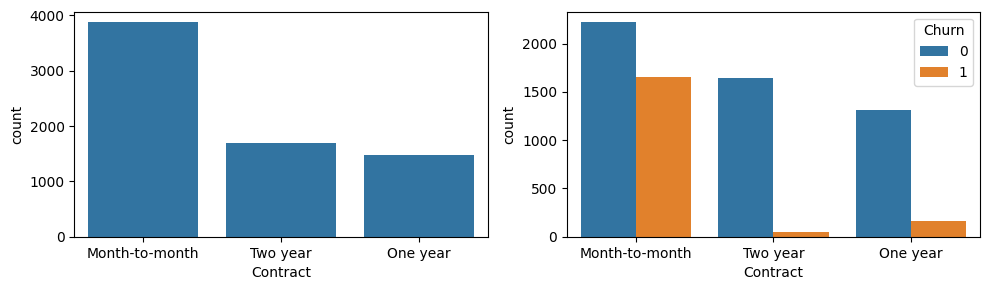

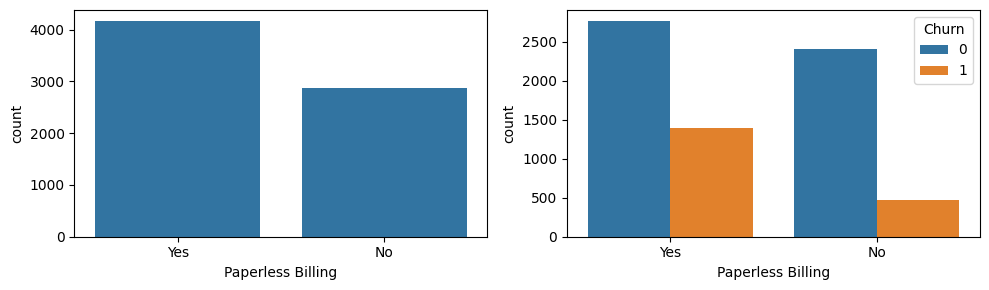

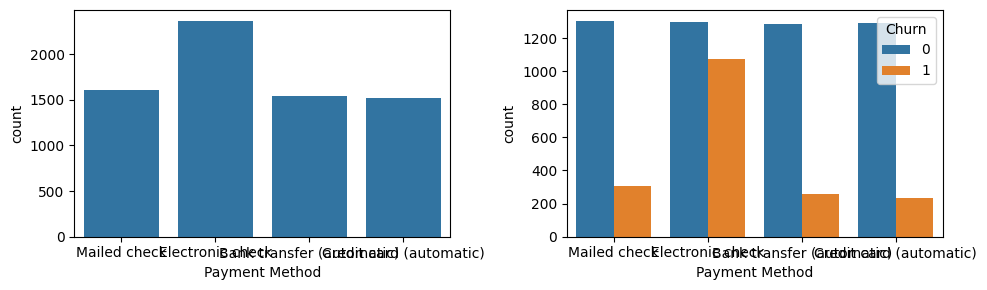

In [20]:
for col in categorical_features:
  fig, Axes = plt.subplots(1, 2, figsize=(10, 3))
  sns.countplot(x=col, data=df, ax=Axes[0])
  sns.countplot(x=col, hue='Churn', data=df, ax=Axes[1])
  plt.tight_layout()
  plt.show()


In [21]:
def cramers_v(chi2, contingency_table):
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

In [22]:
for col in categorical_features:
    contingency_table = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    v = cramers_v(chi2, contingency_table)
    print(f"{col}: chi2={chi2:.2f}, p={p:.4f}, CramersV={v:.3f}")


City: chi2=1233.57, p=0.0150, CramersV=0.419
Gender: chi2=0.48, p=0.4866, CramersV=0.008
Senior Citizen: chi2=159.43, p=0.0000, CramersV=0.150
Partner: chi2=158.73, p=0.0000, CramersV=0.150
Dependents: chi2=433.73, p=0.0000, CramersV=0.248
Phone Service: chi2=0.92, p=0.3388, CramersV=0.011
Multiple Lines: chi2=11.33, p=0.0035, CramersV=0.040
Internet Service: chi2=732.31, p=0.0000, CramersV=0.322
Online Security: chi2=850.00, p=0.0000, CramersV=0.347
Online Backup: chi2=601.81, p=0.0000, CramersV=0.292
Device Protection: chi2=558.42, p=0.0000, CramersV=0.282
Tech Support: chi2=828.20, p=0.0000, CramersV=0.343
Streaming TV: chi2=374.20, p=0.0000, CramersV=0.231
Streaming Movies: chi2=375.66, p=0.0000, CramersV=0.231
Contract: chi2=1184.60, p=0.0000, CramersV=0.410
Paperless Billing: chi2=258.28, p=0.0000, CramersV=0.191
Payment Method: chi2=648.14, p=0.0000, CramersV=0.303


Feature Engineering

In [23]:
# Add: if a cusotmer has Tenure Month less than 6 month categorizing it as Is Newcustomer
df['Is Newcustomer'] = (df['Tenure Months'] <=6).astype(int)


In [24]:
# Add: average monthly spend features in replace for Total Charges
df['Avg Monthly Spend'] = np.where(
    df['Tenure Months'] > 0,
    df['Total Charges'] / df['Tenure Months'],
    df['Monthly Charges']
)

Data Cleaning

In [25]:
# Drop: Total Charges are collinear with Tenure Months and Monthly Charges
# Keep: Average Monthly Spend instead of Total Charges
df = df.drop(columns='Total Charges')

In [26]:
df

,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Churn,Is Newcustomer,Avg Monthly Spend
0,Los Angeles,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,1,1,54.075000
1,Los Angeles,Female,No,No,Yes,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,1,1,75.825000
2,Los Angeles,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,1,0,102.562500
3,Los Angeles,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,1,0,108.787500
4,Los Angeles,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,1,0,102.781633
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Landers,Female,No,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,0,0,19.713889
7039,Adelanto,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,0,0,82.937500
7040,Amboy,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,0,0,102.262500
7041,Angelus Oaks,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,0,0,31.495455


In [27]:
# Seperating Input Features and Target Variable
X = df.drop(columns=['Churn'])
y = df['Churn']

Train/Test Split

In [29]:
# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y)

In [30]:
# Add: in City we have multiple cities we are considering only top 10 by there name else will be categories as "Other"
top_cities = X_train['City'].value_counts().index[:10].tolist()
def grouped_city(city):
  if city in top_cities:
    return city
  else:
    return 'Other'

In [31]:
# Apply: function what we have just created
X_train = X_train.copy()
X_test = X_test.copy()
X_train['Grouped City'] = X_train['City'].apply(grouped_city)
X_test['Grouped City'] = X_test['City'].apply(grouped_city)
X_train = X_train.drop(columns=['City'])
X_test = X_test.drop(columns=['City'])

In [ ]:
print(X_train.shape, X_test.shape)
print("top cities (train only):", top_cities)

(5634, 21) (1409, 21)
top cities (train only): ['Los Angeles', 'San Diego', 'San Jose', 'Sacramento', 'San Francisco', 'Fresno', 'Long Beach', 'Oakland', 'Glendale', 'Berkeley']


Preprocessing : CloumnTransformer + Pipeline

In [32]:
# Separate: numeric features for scaling, binary features for ordinal encoding, categorical features for one_hot_encoding
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()
binary_int_features = ['Is Newcustomer']
numeric_features = [c for c in numeric_features if c not in binary_int_features]
yes_no_values = {"Yes", "No"}
binary_yes_no = [c for c in categorical_features
                 if set(X_train[c].dropna().unique()) <=yes_no_values]
other_cat_features = [c for c in categorical_features if c not in binary_yes_no]

In [33]:
print("numeric:", numeric_features)
print("binary 0/1 passthrough:", binary_int_features)
print("yes/no:", binary_yes_no)
print("other cat (one-hot):", other_cat_features)

numeric: ['Tenure Months', 'Monthly Charges', 'Avg Monthly Spend']
binary 0/1 passthrough: ['Is Newcustomer']
yes/no: ['Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Paperless Billing']
other cat (one-hot): ['Gender', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Payment Method', 'Grouped City']


In [34]:
# Pipeline: numeric-> impute(median) -> scale
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline: binary -> impute(most frequent) -> ordinal encoding
binary_cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[["No", "Yes"]] * len(binary_yes_no) if binary_yes_no else auto,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

# Pipeline: categorical -> impute(most frequent)-> one_hot encoding
nonbinary_cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# tranformer: column transformation
transformer =[
    ("numeric", numeric_pipeline, numeric_features),
    ("binary_int", "passthrough", binary_int_features),
    ("nonbinary_cat", nonbinary_cat_pipeline, other_cat_features),
]
if binary_yes_no:
    transformer.insert(2, ("binary_yes_no", binary_cat_pipeline, binary_yes_no))
preprocessor = ColumnTransformer(transformers=transformer)

In [35]:
# Preprocessor pipeline look like this
preprocessor

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Tenure Months', 'Monthly Charges',
                                  'Avg Monthly Spend']),
                                ('binary_int', 'passthrough',
                                 ['Is Newcustomer']),
                                ('binary_yes_no',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(categ...
                                  'Phone Service', 'Paperless Billing']),
                                ('nonbinary_cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['Gender', 'Multiple Lines',
                                  'Internet Service', 'Online Security',
                                  'Online Backup', 'Device Protection',
                                  'Tech Support', 'Streaming TV',
                                  'Streaming Movies', 'Contract',
                                  'Payment Method', 'Grouped City'])])

Trying Multiple Models

In [36]:
# Training: multiple models on there default parameter to check which one is performing best
models = {
    'Logistic Regression': LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'SVM': SVC(class_weight="balanced", random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss')
}

In [37]:
#'roc_auc': 'roc_auc' — Measures how well the model separates the two classes (like "churn" vs "no churn") across all decision thresholds. Closer to 1.0 is better.
# 'pr_auc': 'average_precision' — Similar idea, but focuses on precision and recall. This is especially useful when one class is rare (e.g., only 5% of customers churn) — it doesn't get fooled by imbalanced data the way plain accuracy can.
# 'accuracy': 'accuracy' — The simplest one: what percentage of predictions were correct overall.
# 'f1_churn': 'f1' — Balances precision and recall for the "churn" class specifically. Useful when you care about catching churners without too many false alarms.
scoring = {
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'accuracy': 'accuracy',
    'f1_churn': 'f1'
}

In [38]:
for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    scores = cross_validate(pipe, X_train, y_train, cv=CV, scoring=scoring, n_jobs=-1)
    print(f"{name} -> "
          f"ROC-AUC {scores['test_roc_auc'].mean():.3f} | "
          f"PR-AUC {scores['test_pr_auc'].mean():.3f} | "
          f"F1(churn) {scores['test_f1_churn'].mean():.3f} | "
          f"Acc {scores['test_accuracy'].mean():.3f}"
    )




Logistic Regression -> ROC-AUC 0.860 | PR-AUC 0.679 | F1(churn) 0.645 | Acc 0.764
Decision Tree -> ROC-AUC 0.672 | PR-AUC 0.396 | F1(churn) 0.518 | Acc 0.745
Random Forest -> ROC-AUC 0.842 | PR-AUC 0.637 | F1(churn) 0.567 | Acc 0.798
KNN -> ROC-AUC 0.767 | PR-AUC 0.490 | F1(churn) 0.547 | Acc 0.761
SVM -> ROC-AUC 0.852 | PR-AUC 0.647 | F1(churn) 0.644 | Acc 0.764
XGBoost -> ROC-AUC 0.839 | PR-AUC 0.641 | F1(churn) 0.584 | Acc 0.793


Logistic Regression is quietly the best overall. It wins on ROC-AUC, PR-AUC, and F1 — the three metrics that matter most for churn prediction (where churners are usually the minority class).

Hyperparameter Tuning

In [39]:
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE))
])

param_grid = [
    {
        'classifier__solver': ['saga'],
        'classifier__penalty': ['l1'],
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__max_iter': [200, 300, 400, 500],
    },
    {
        'classifier__solver': ['saga'],
        'classifier__penalty': ['elasticnet'],
        'classifier__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__max_iter': [200, 300, 400, 500],
    },
    {
        'classifier__solver': ['lbfgs'],
        'classifier__penalty': ['l2'],
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__max_iter': [200, 300, 400, 500],
    },
]

random_search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_grid,
    n_iter=60,
    cv=CV,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)


Training the model on traning dataset

In [40]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numeric',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Tenure '
                                                                                'Months',
                                                                                'Monthly '
                                                                                'Charges',
                                                                                'Avg '
                                                                                'Monthly '
                                                                                'Spend']),
                                                                              ('binary_int',
                                                                               'passthrough',
                                                                               ['Is '
                                                                                '...
                                                           10, 100],
                                         'classifier__l1_ratio': [0.1, 0.3, 0.5,
                                                                  0.7, 0.9],
                                         'classifier__max_iter': [200, 300, 400,
                                                                  500],
                                         'classifier__penalty': ['elasticnet'],
                                         'classifier__solver': ['saga']},
                                        {'classifier__C': [0.001, 0.01, 0.1, 1,
                                                           10, 100],
                                         'classifier__max_iter': [200, 300, 400,
                                                                  500],
                                         'classifier__penalty': ['l2'],
                                         'classifier__solver': ['lbfgs']}],
                   random_state=42, scoring='roc_auc', verbose=1)

In [41]:
# best parameters that randomized search cv pick with best score
print(random_search.best_params_)
print(random_search.best_score_)

{'classifier__solver': 'saga', 'classifier__penalty': 'elasticnet', 'classifier__max_iter': 300, 'classifier__l1_ratio': 0.1, 'classifier__C': 0.1}
0.8605496099277001


Final Evaluation on the Test Set

In [42]:
churn_pipeline = random_search.best_estimator_
y_proba = churn_pipeline.predict_proba(X_test)[:, 1]

In [54]:
#sets a decision boundary. Any customer with a churn probability at or above this number gets labeled as "will churn." Below it, they're labeled "won't churn."
THRESHOLD = 0.7
y_pred = (y_proba >= THRESHOLD).astype(int)

In [55]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[897 138]
 [149 225]]
ROC-AUC: 0.8524348342762663
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      1035
           1       0.62      0.60      0.61       374

    accuracy                           0.80      1409
   macro avg       0.74      0.73      0.74      1409
weighted avg       0.79      0.80      0.80      1409



If catching churners matters more than avoiding false alarms (which it usually does — losing a customer is expensive, sending an unnecessary discount is cheap), this is actually a pretty reasonable tradeoff. You're catching 4 out of 5 real churners, at the cost of some wasted retention offers on people who were staying anyway.

If you wanted to shift this balance, you could lower the threshold below 0.5 to catch even more churners (recall ↑) at the cost of even more false alarms (precision ↓) — or raise it if false alarms are getting too costly.